In [46]:
from __future__ import annotations

import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import train_test_split

%matplotlib inline

# Paths + sanity checks (из main.ipynb, адаптировано под этот ноутбук)
BASE_PATH = Path("./onti-students-performance")
X_TRAIN_PATH = BASE_PATH / "X_train.csv"
X_TEST_PATH = BASE_PATH / "X_test.csv"
Y_TRAIN_PATH = BASE_PATH / "y_train.csv"
STUDS_INFO_PATH = BASE_PATH / "studs_info.csv"
SAMPLE_SUB_PATH = BASE_PATH / "sample_submission.csv"

missing = [str(p) for p in [X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, STUDS_INFO_PATH, SAMPLE_SUB_PATH] if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required data files:\n" + "\n".join(missing))

# Hardware-aware parallelism: avoid nested parallelism (search parallelizes, RF itself runs single-threaded during search)
CPU_COUNT = os.cpu_count() or 1
N_JOBS = min(8, CPU_COUNT)
print(f"CPU_COUNT={CPU_COUNT}, N_JOBS={N_JOBS}")


CPU_COUNT=8, N_JOBS=8


/home/aliaksandr/BSUIR/students_performance/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def result_pred(pred, resY):
    print(f'mean_squared_error: {math.sqrt(mean_squared_error(resY, pred))}')
    print(f'mean_absolute_error: {mean_absolute_error(resY, pred)}')
    print(f'median_absolute_error: {median_absolute_error(resY, pred)}')
    print(f'mean_absolute_percentage_error: {mean_absolute_percentage_error(resY, pred)}')
    print(f'r2_score: {r2_score(resY, pred)}')

In [3]:
def result_value(pred, resY):
    return [math.sqrt(mean_squared_error(resY, pred)),
            mean_absolute_error(resY, pred),
            median_absolute_error(resY, pred),
            mean_absolute_percentage_error(resY, pred),
            r2_score(resY, pred)]

In [4]:
def result_table(args, resY, subcol=None, valueSubCol=None):
    if subcol and valueSubCol:
        dt = {subcol: valueSubCol,
            'mean_squared_error': [],
            'mean_absolute_error': [],
            'median_absolute_error': [],
            'mean_absolute_percentage_error': [],
            'r2_score': []}
    else:
        dt = {'mean_squared_error': [],
            'mean_absolute_error': [],
            'median_absolute_error': [],
            'mean_absolute_percentage_error': [],
            'r2_score': []}
    preds = args
    for pred in preds:
        tmp = result_value(pred, resY)
        dt['mean_squared_error'].append(tmp[0])
        dt['mean_absolute_error'].append(tmp[1])
        dt['median_absolute_error'].append(tmp[2])
        dt['mean_absolute_percentage_error'].append(tmp[3])
        dt['r2_score'].append(tmp[4])
    return dt

# Анализ данных

In [5]:
data = pd.read_csv(X_TRAIN_PATH)
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

In [6]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг..."
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия
...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика


## Параллельный анализ

### studs_info

In [7]:
studs_info = pd.read_csv('./onti-students-performance/studs_info.csv').rename(columns={'   ': 'number2', '   number': 'number1'})

In [8]:
studs_info

,STD_ID,number1,Пол,Статус,Дата выпуска,Категория обучения,Форма обучения,Шифр,направление (специальность),number2,Образование,Дата выдачи,Что именно закончил
0,99136,13951.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2629.0,СР,2013-06-26 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
1,99112,13998.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,8240.0,СР,2012-06-23 00:00:00,"МОУ СОШ N 2, ПЕСТОВО"
2,99109,13999.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2314.0,СР,2013-06-25 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
3,99125,13953.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2345.0,СР,2013-06-23 00:00:00,"Гимназия ""ГАРМОНИЯ"""
4,100676,13950.0,М,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2650.0,СР,2012-06-29 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5461,100678,978.0,Ж,СТ,NaN,БП,Д,31.05.01,Лечебное дело,2388.0,СР,2013-06-21 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5462,100663,1021.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,2554.0,СР,2013-06-27 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5463,191630,6447.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,6692.0,СР,2014-05-31 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5464,191625,3765.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,NaN,NaN,NaN,NaN


In [9]:
studs_info[studs_info['STD_ID'] == 149499]

,STD_ID,number1,Пол,Статус,Дата выпуска,Категория обучения,Форма обучения,Шифр,направление (специальность),number2,Образование,Дата выдачи,Что именно закончил
5106,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,311.0,СР,2006-06-25 00:00:00,Панковская СОШ НОВГОРОДСКИЙ р-н
5107,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,316.0,СР,NaN,"СРЕДНЯЯ ШКОЛА N 4, НОВГОРОД"
5108,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,9542.0,СП,2008-06-27 00:00:00,Аграрный техникум г.Новгород


In [10]:
studs_info.isnull().sum()

STD_ID                            0
number1                           1
Пол                               1
Статус                            1
Дата выпуска                   5002
Категория обучения                1
Форма обучения                    1
Шифр                              1
направление (специальность)       1
number2                         191
Образование                     191
Дата выдачи                     240
Что именно закончил             191
dtype: int64

In [11]:
studs_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5466 entries, 0 to 5465
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   STD_ID                       5466 non-null   int64  
 1   number1                      5465 non-null   float64
 2   Пол                          5465 non-null   object 
 3   Статус                       5465 non-null   object 
 4   Дата выпуска                 464 non-null    object 
 5   Категория обучения           5465 non-null   object 
 6   Форма обучения               5465 non-null   object 
 7   Шифр                         5465 non-null   object 
 8   направление (специальность)  5465 non-null   object 
 9   number2                      5275 non-null   float64
 10  Образование                  5275 non-null   object 
 11  Дата выдачи                  5226 non-null   object 
 12  Что именно закончил          5275 non-null   object 
dtypes: float64(2), int

In [12]:
studs_info = studs_info.drop(columns=['Дата выпуска', 'Шифр', 'направление (специальность)', 'Дата выдачи'])

In [13]:
studs_info.isnull().sum()

STD_ID                   0
number1                  1
Пол                      1
Статус                   1
Категория обучения       1
Форма обучения           1
number2                191
Образование            191
Что именно закончил    191
dtype: int64

In [14]:
studs_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5466 entries, 0 to 5465
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   STD_ID               5466 non-null   int64  
 1   number1              5465 non-null   float64
 2   Пол                  5465 non-null   object 
 3   Статус               5465 non-null   object 
 4   Категория обучения   5465 non-null   object 
 5   Форма обучения       5465 non-null   object 
 6   number2              5275 non-null   float64
 7   Образование          5275 non-null   object 
 8   Что именно закончил  5275 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 384.5+ KB


In [15]:
studs_info

,STD_ID,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,99136,13951.0,Ж,ВЫП,БП,Д,2629.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
1,99112,13998.0,Ж,ВЫП,БП,Д,8240.0,СР,"МОУ СОШ N 2, ПЕСТОВО"
2,99109,13999.0,Ж,ВЫП,БП,Д,2314.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
3,99125,13953.0,Ж,ВЫП,БП,Д,2345.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,100676,13950.0,М,ВЫП,БП,Д,2650.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...
5461,100678,978.0,Ж,СТ,БП,Д,2388.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5462,100663,1021.0,Ж,СТ,ДОГ,Д,2554.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5463,191630,6447.0,Ж,СТ,ДОГ,Д,6692.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5464,191625,3765.0,Ж,СТ,ДОГ,Д,NaN,NaN,NaN


In [16]:
studs_info['STD_ID'].value_counts()

STD_ID
182225    3
149499    3
176688    3
164799    3
171774    3
         ..
189770    1
188657    1
195160    1
194832    1
188959    1
Name: count, Length: 5104, dtype: int64

In [17]:
studs_info = studs_info.drop_duplicates(['STD_ID'])

In [18]:
studs_info['number1'] = studs_info['number1'].fillna(studs_info['number1'].mean())
studs_info['Пол'] = studs_info['Пол'].fillna(studs_info['Пол'].value_counts().keys()[0])
studs_info['Статус'] = studs_info['Статус'].fillna(studs_info['Статус'].value_counts().keys()[0])
studs_info['Категория обучения'] = studs_info['Категория обучения'].fillna(studs_info['Категория обучения'].value_counts().keys()[0])
studs_info['Форма обучения'] = studs_info['Форма обучения'].fillna(studs_info['Форма обучения'].value_counts().keys()[0])
studs_info['number2'] = studs_info['number2'].fillna(studs_info['number2'].mean())
studs_info['Образование'] = studs_info['Образование'].fillna(studs_info['Образование'].value_counts().keys()[0])
studs_info['Что именно закончил'] = studs_info['Что именно закончил'].fillna(studs_info['Что именно закончил'].value_counts().keys()[0])

/tmp/ipykernel_32652/3546395353.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  studs_info['number1'] = studs_info['number1'].fillna(studs_info['number1'].mean())
/tmp/ipykernel_32652/3546395353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  studs_info['Пол'] = studs_info['Пол'].fillna(studs_info['Пол'].value_counts().keys()[0])
/tmp/ipykernel_32652/3546395353.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [19]:
studs_info.isnull().sum()

STD_ID                 0
number1                0
Пол                    0
Статус                 0
Категория обучения     0
Форма обучения         0
number2                0
Образование            0
Что именно закончил    0
dtype: int64

In [20]:
pd.read_csv('./onti-students-performance/studs_info.csv')['STD_ID'].unique()

array([ 99136,  99112,  99109, ..., 191630, 191625, 194978], shape=(5104,))

In [21]:
data['STD_ID'].unique()

array([175711, 100647, 199311, ..., 162272, 200391, 194047], shape=(5084,))

In [22]:
data = data.merge(studs_info, how='left', on='STD_ID').dropna()

In [23]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг,3989.0,М,СТ,БП,Д,5445.0,СР,"СРЕДНЯЯ ШКОЛА N 31, НОВГОРОД"
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг...",14025.0,Ж,ВЫП,ДОГ,Д,2668.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия,7212.0,Ж,СТ,БП,Д,11431.0,СР,"ГИМНАЗИЯ N 2, НОВГОРОД"
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика,3293.0,М,СТ,БП,Д,4981.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия,875.0,Ж,СТ,ДОГ,Д,2034.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право,861.0,Ж,СТ,ДОГ,В,8613.0,СР,"МОУ СОШ N 1, СОЛЬЦЫ с филиалом в Куклино"
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология,3859.0,Ж,СТ,ДОГ,Д,5505.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык,6989.0,Ж,СТ,БП,Д,4900.0,СР,"ГИМНАЗИЯ N 1, НОВГОРОД"
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика,4091.0,Ж,СТ,ДОГ,З,5466.0,СР,"Гимназия ""ГАРМОНИЯ"""


In [24]:
pd.read_csv('./onti-students-performance/y_train.csv')

,index,mark
0,51081,5
1,72921,5
2,96438,5
3,273044,4
4,371309,3
...,...,...
105053,224856,3
105054,260998,3
105055,57245,4
105056,218529,4


## Дальше анализируем дату

In [25]:
data.isnull().sum()

STD_ID                 0
НАПРАВЛЕНИЕ            0
ГОД                    0
КУРС                   0
СЕМЕСТР                0
АТТЕСТАЦИЯ             0
ДИСЦИПЛИНА             0
number1                0
Пол                    0
Статус                 0
Категория обучения     0
Форма обучения         0
number2                0
Образование            0
Что именно закончил    0
dtype: int64

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105058 entries, 0 to 105057
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   STD_ID               105058 non-null  int64  
 1   НАПРАВЛЕНИЕ          105058 non-null  object 
 2   ГОД                  105058 non-null  object 
 3   КУРС                 105058 non-null  float64
 4   СЕМЕСТР              105058 non-null  float64
 5   АТТЕСТАЦИЯ           105058 non-null  object 
 6   ДИСЦИПЛИНА           105058 non-null  object 
 7   number1              105058 non-null  float64
 8   Пол                  105058 non-null  object 
 9   Статус               105058 non-null  object 
 10  Категория обучения   105058 non-null  object 
 11  Форма обучения       105058 non-null  object 
 12  number2              105058 non-null  float64
 13  Образование          105058 non-null  object 
 14  Что именно закончил  105058 non-null  object 
dtypes: float64(4), in

In [27]:
data.shape

(105058, 15)

In [28]:
data.drop_duplicates().shape

(105058, 15)

In [29]:
data = data.drop_duplicates()

## Посмотрим на котегориальные признаки

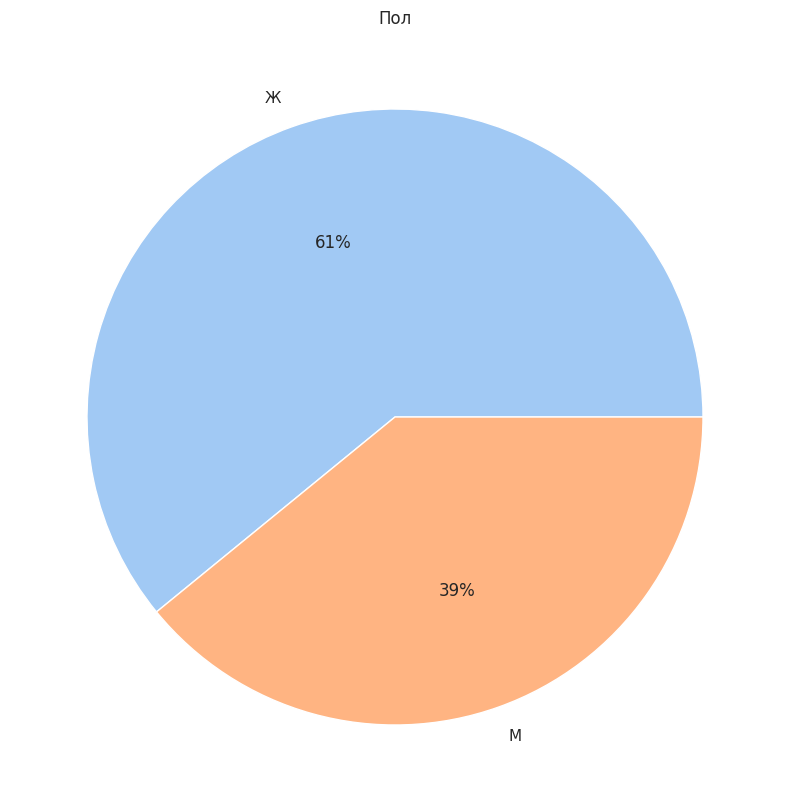

In [30]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Пол'].unique())
dt = np.array([len(data[data['Пол'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Пол')
plt.show()

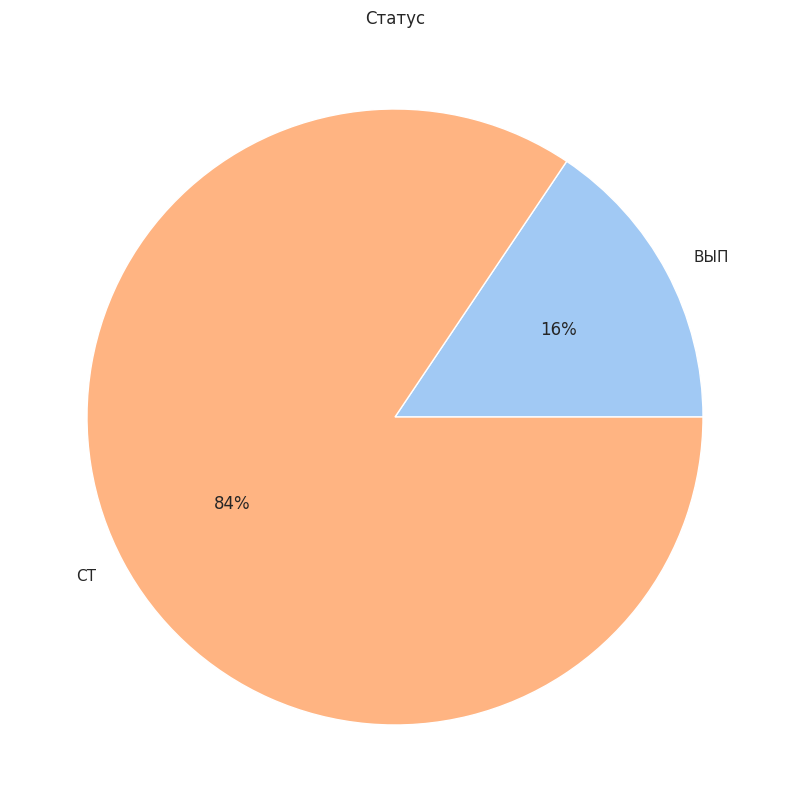

In [31]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Статус'].unique())
dt = np.array([len(data[data['Статус'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Статус')
plt.show()

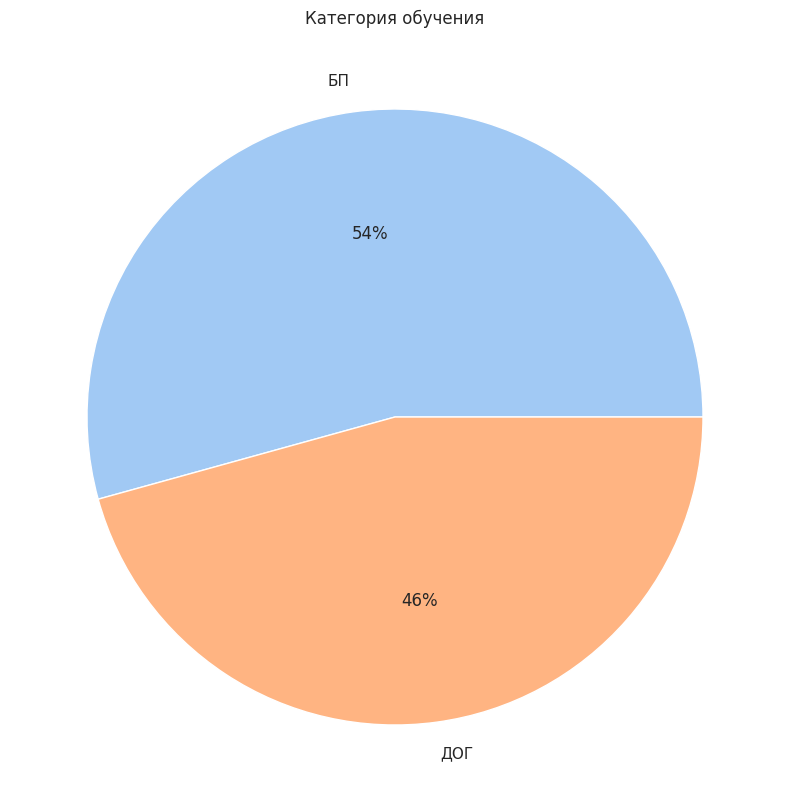

In [32]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Категория обучения'].unique())
dt = np.array([len(data[data['Категория обучения'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Категория обучения')
plt.show()

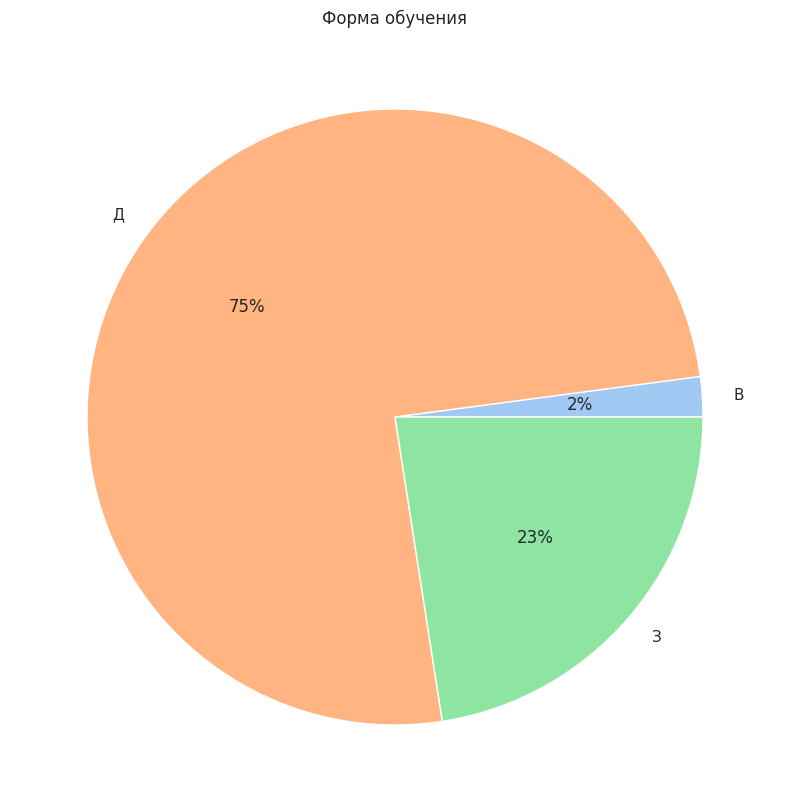

In [33]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Форма обучения'].unique())
dt = np.array([len(data[data['Форма обучения'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Форма обучения')
plt.show()

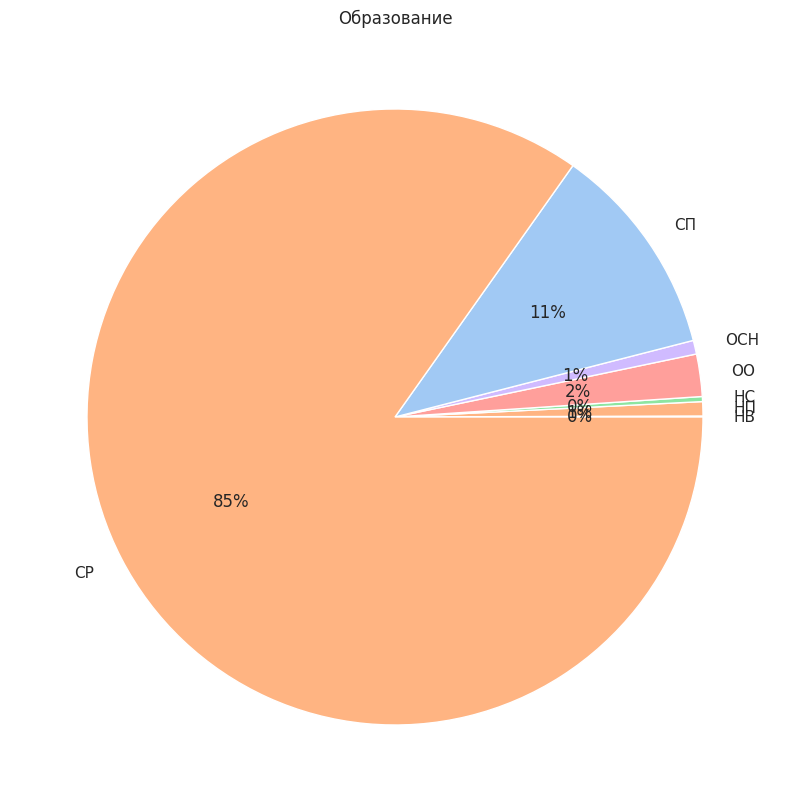

In [34]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Образование'].unique())
dt = np.array([len(data[data['Образование'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Образование')
plt.show()

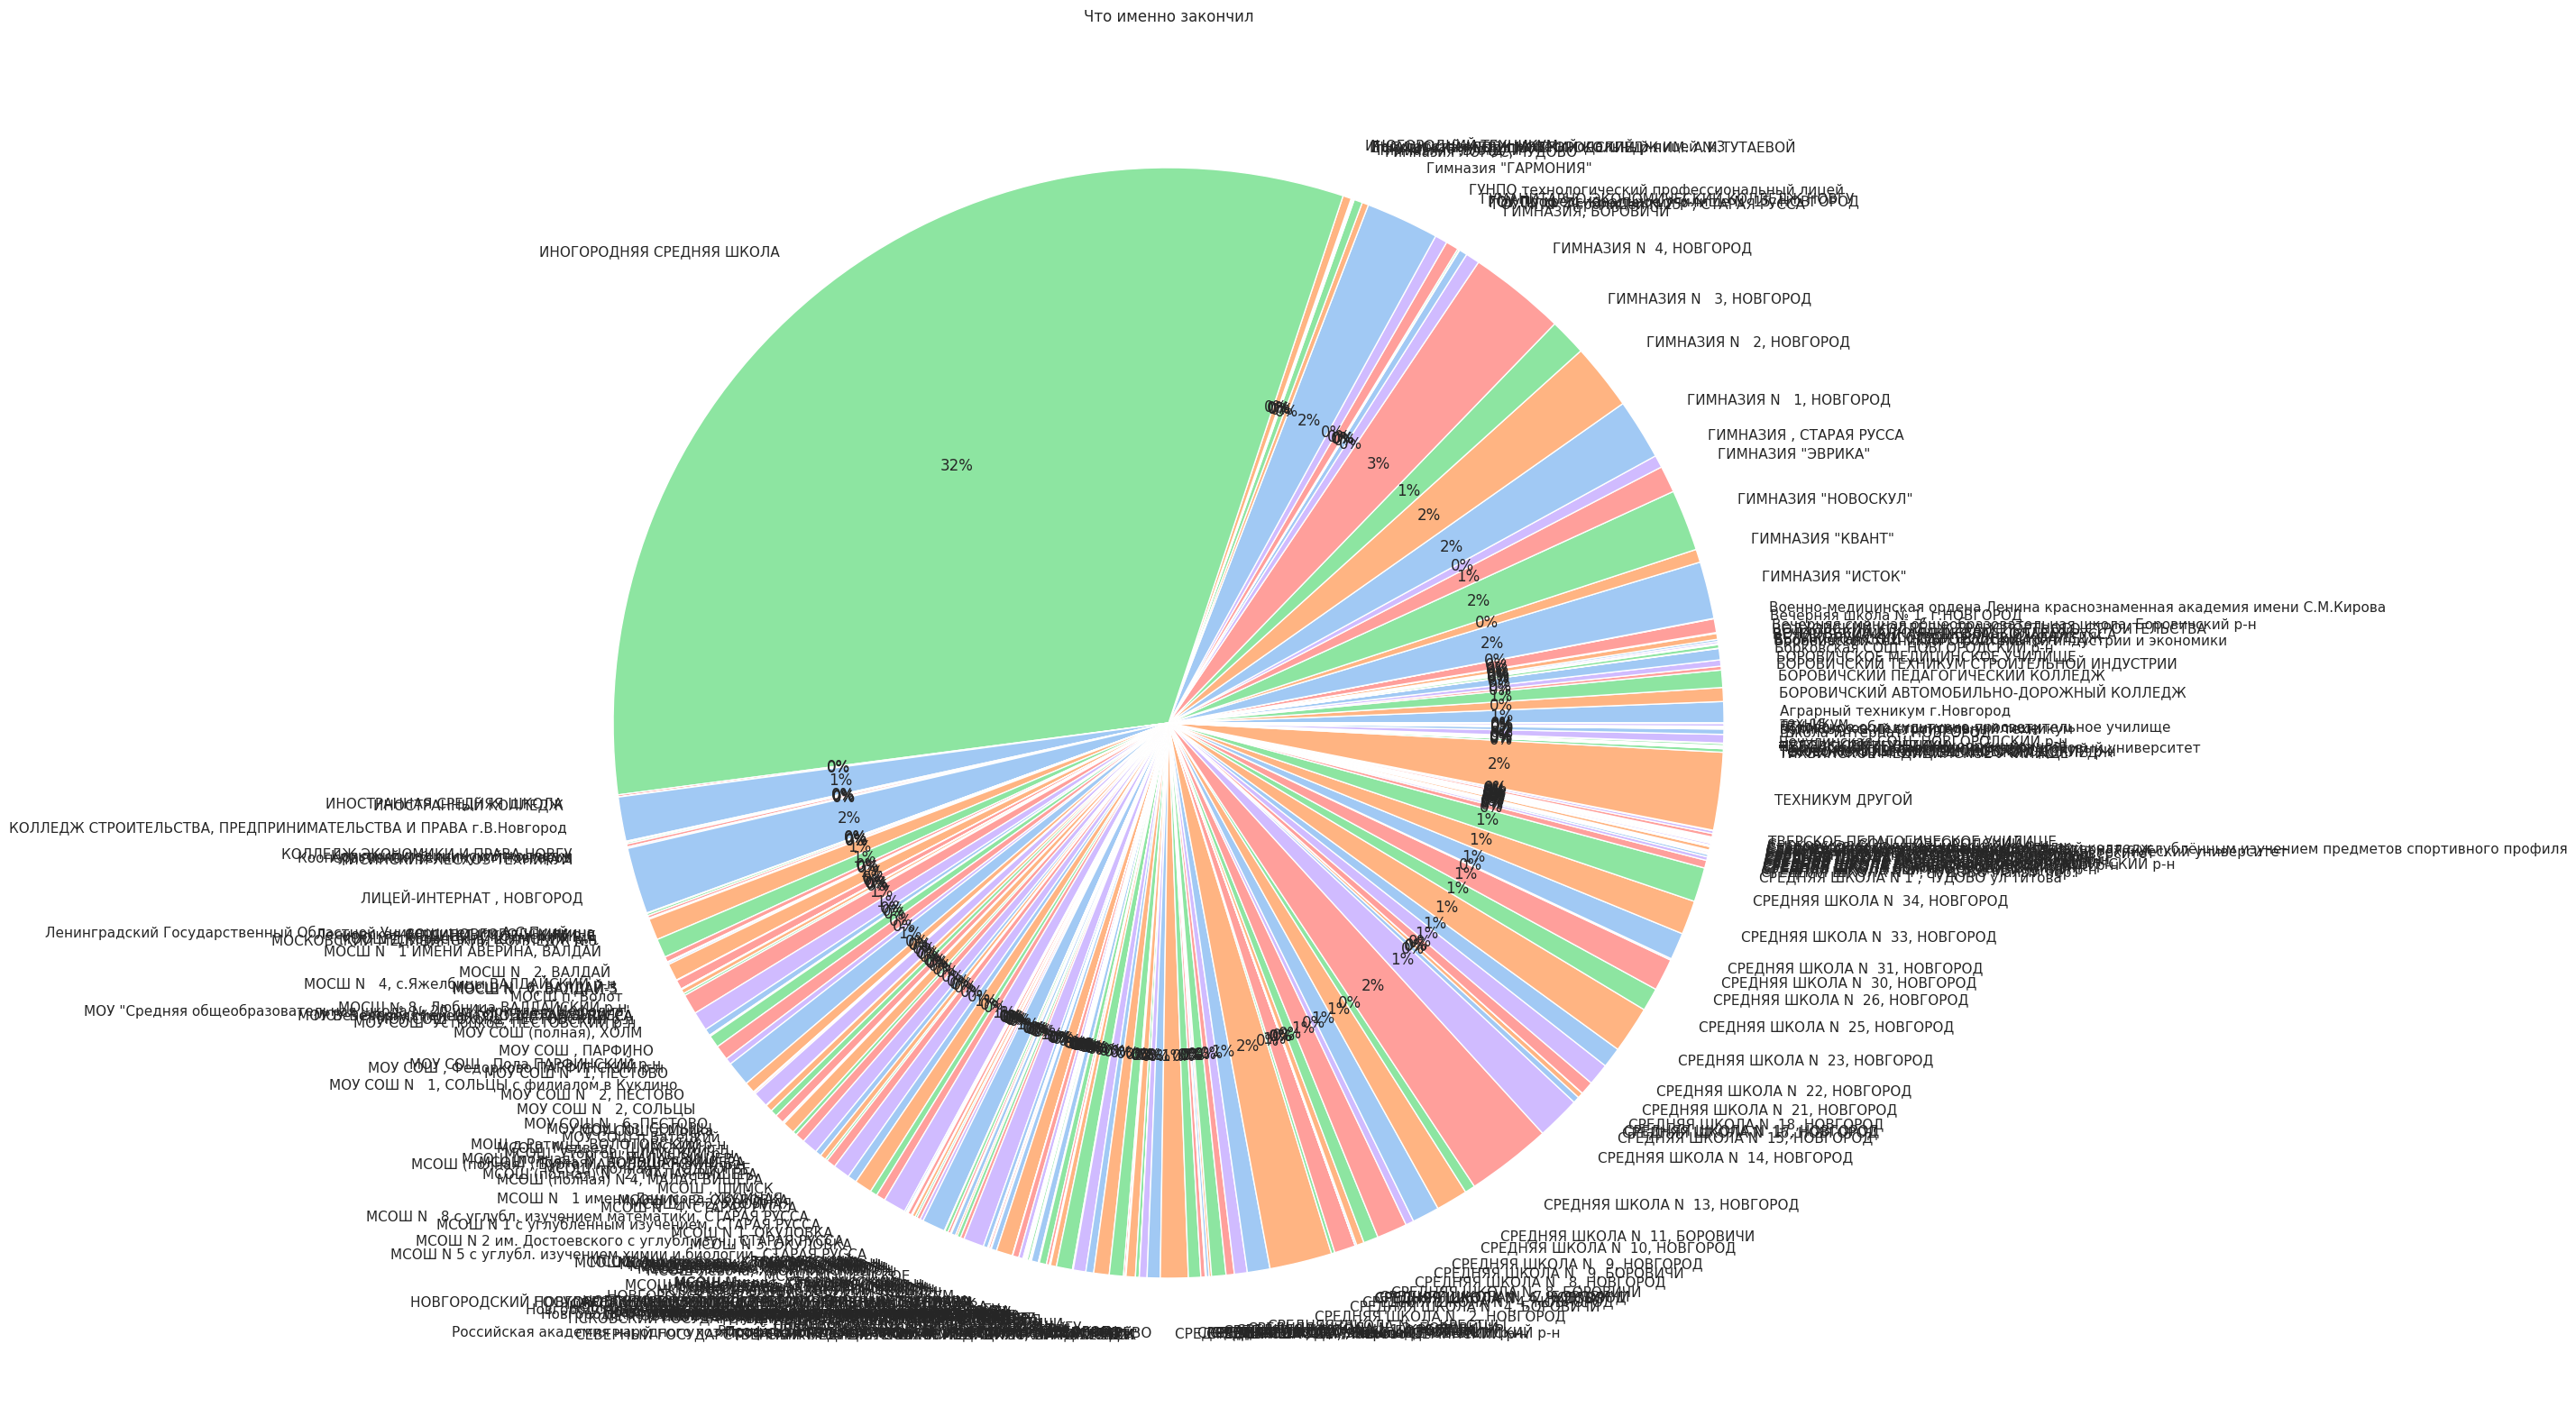

In [35]:
sns.set(rc={'figure.figsize': (20, 20)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Что именно закончил'].unique())
dt = np.array([len(data[data['Что именно закончил'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Что именно закончил')
plt.show()

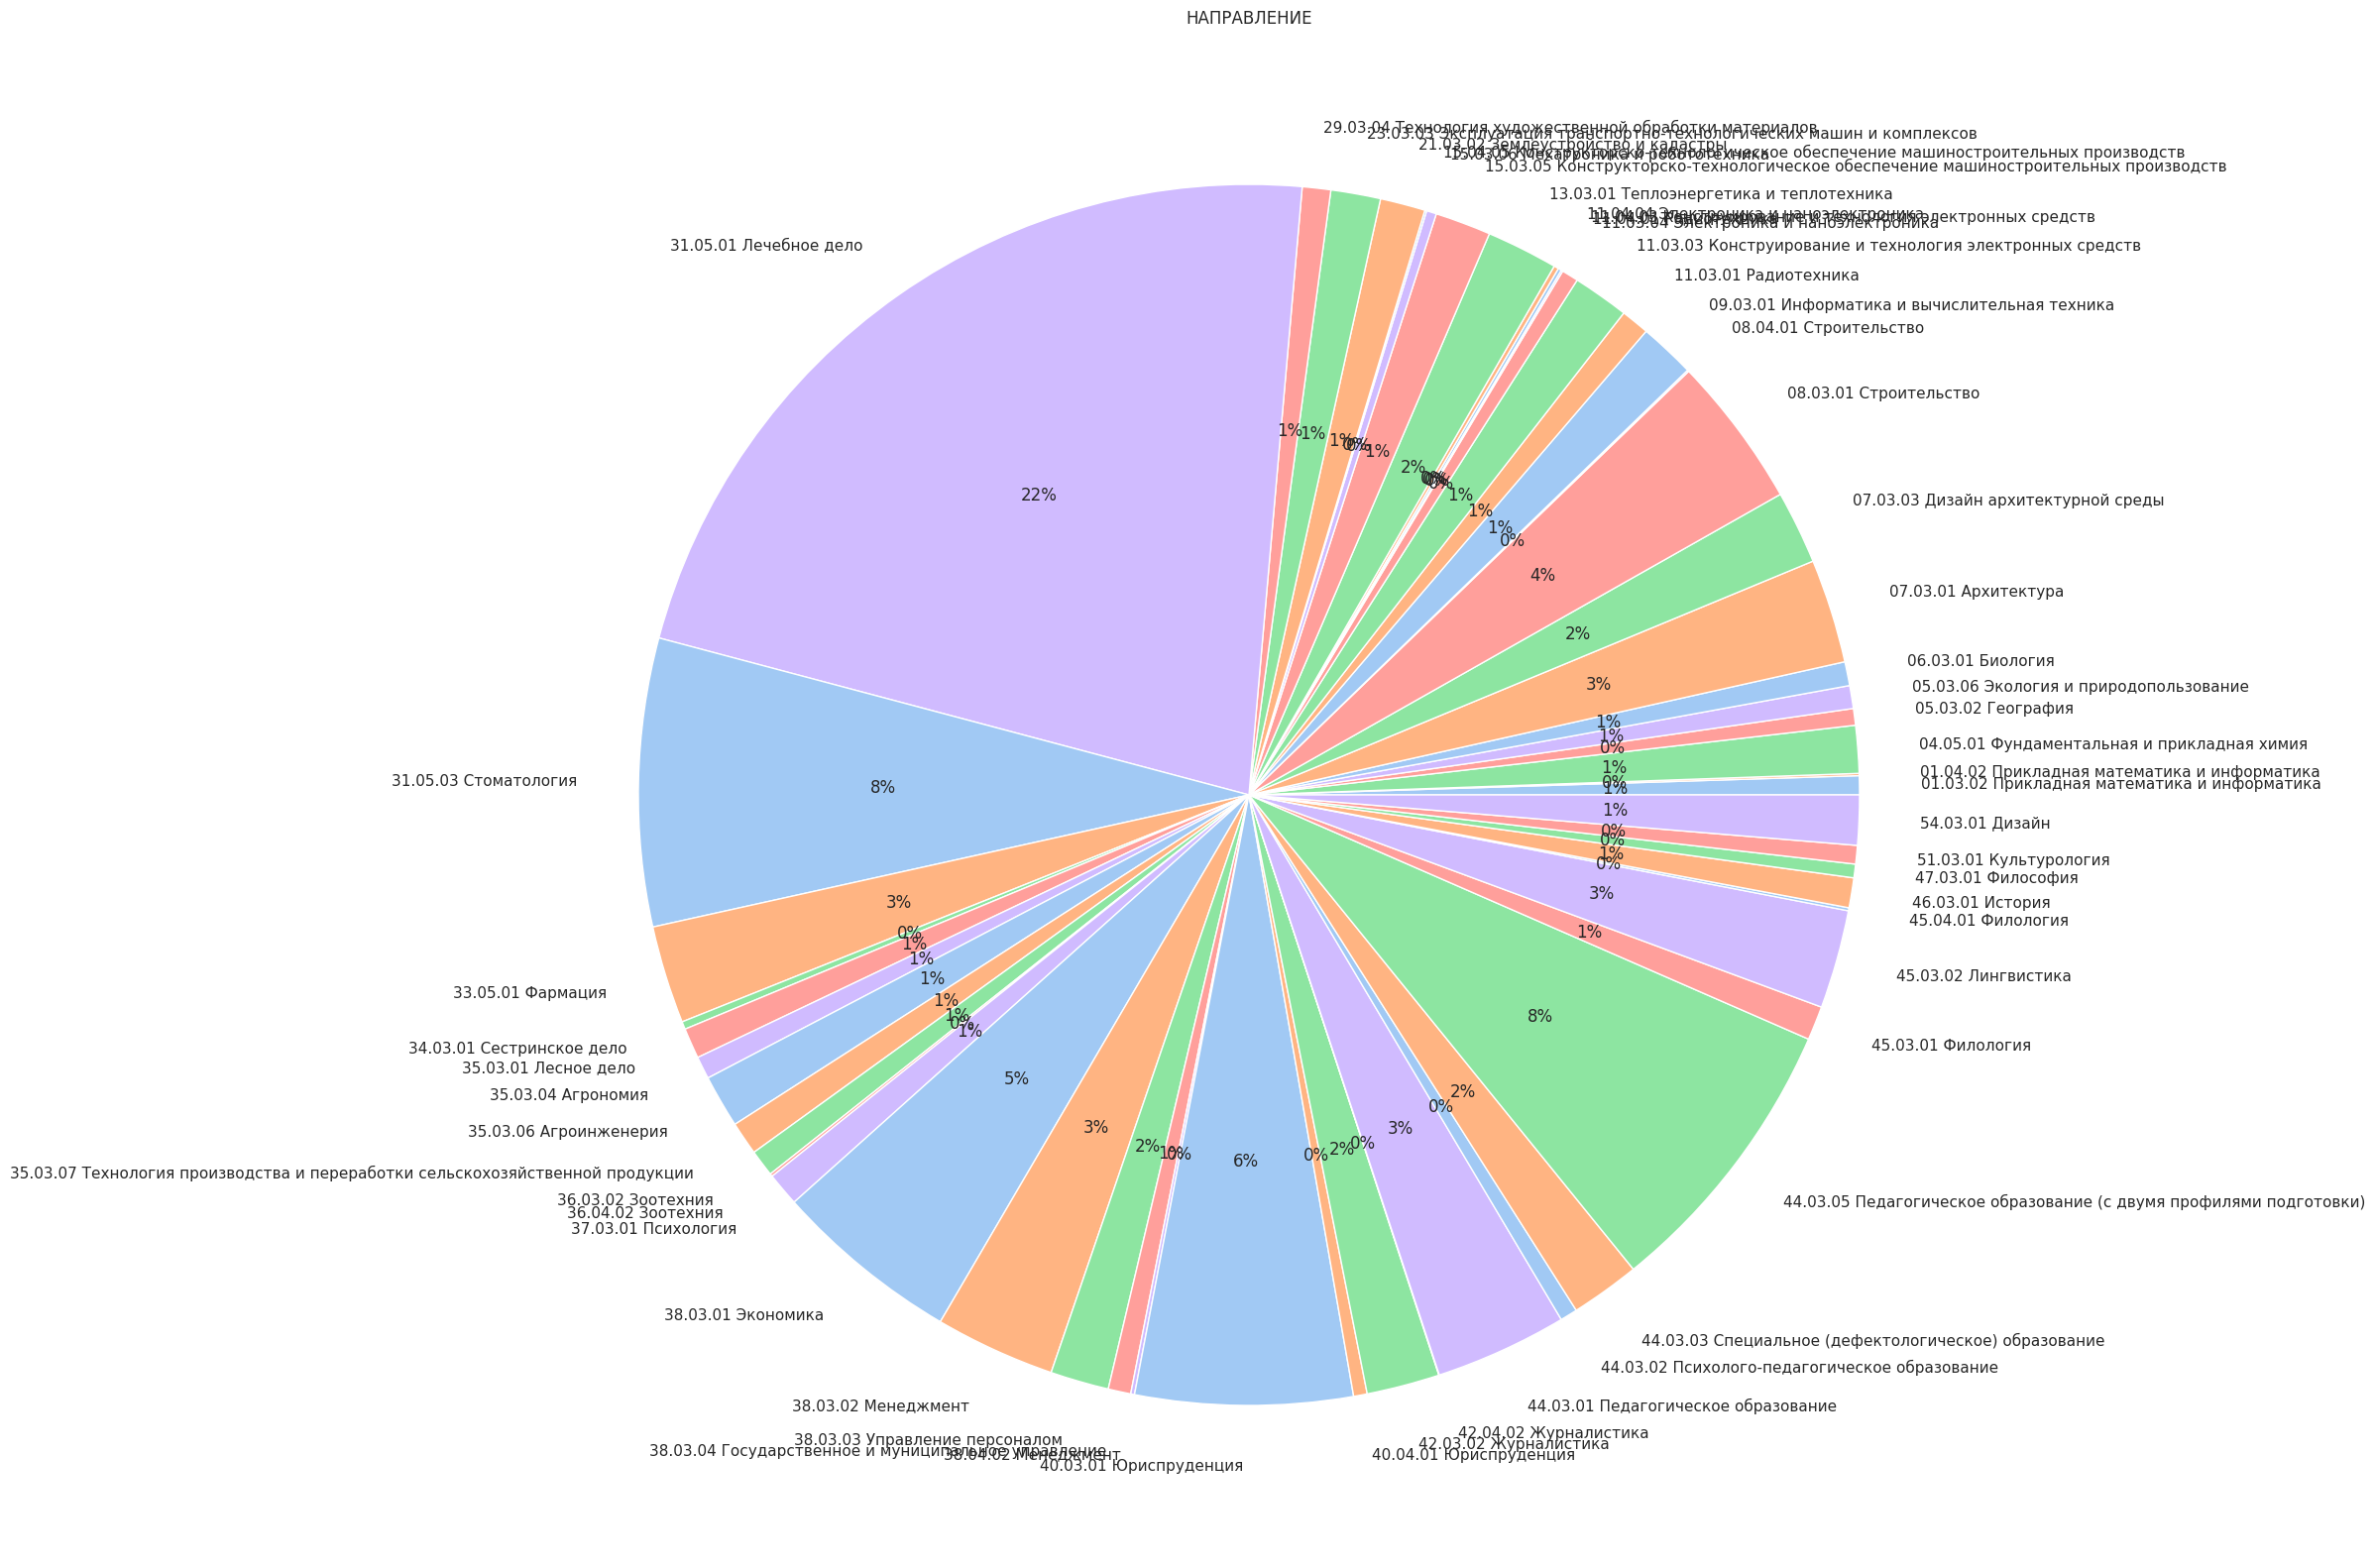

In [36]:
sns.set(rc={'figure.figsize': (20, 20)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['НАПРАВЛЕНИЕ'].unique())
dt = np.array([len(data[data['НАПРАВЛЕНИЕ'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('НАПРАВЛЕНИЕ')
plt.show()

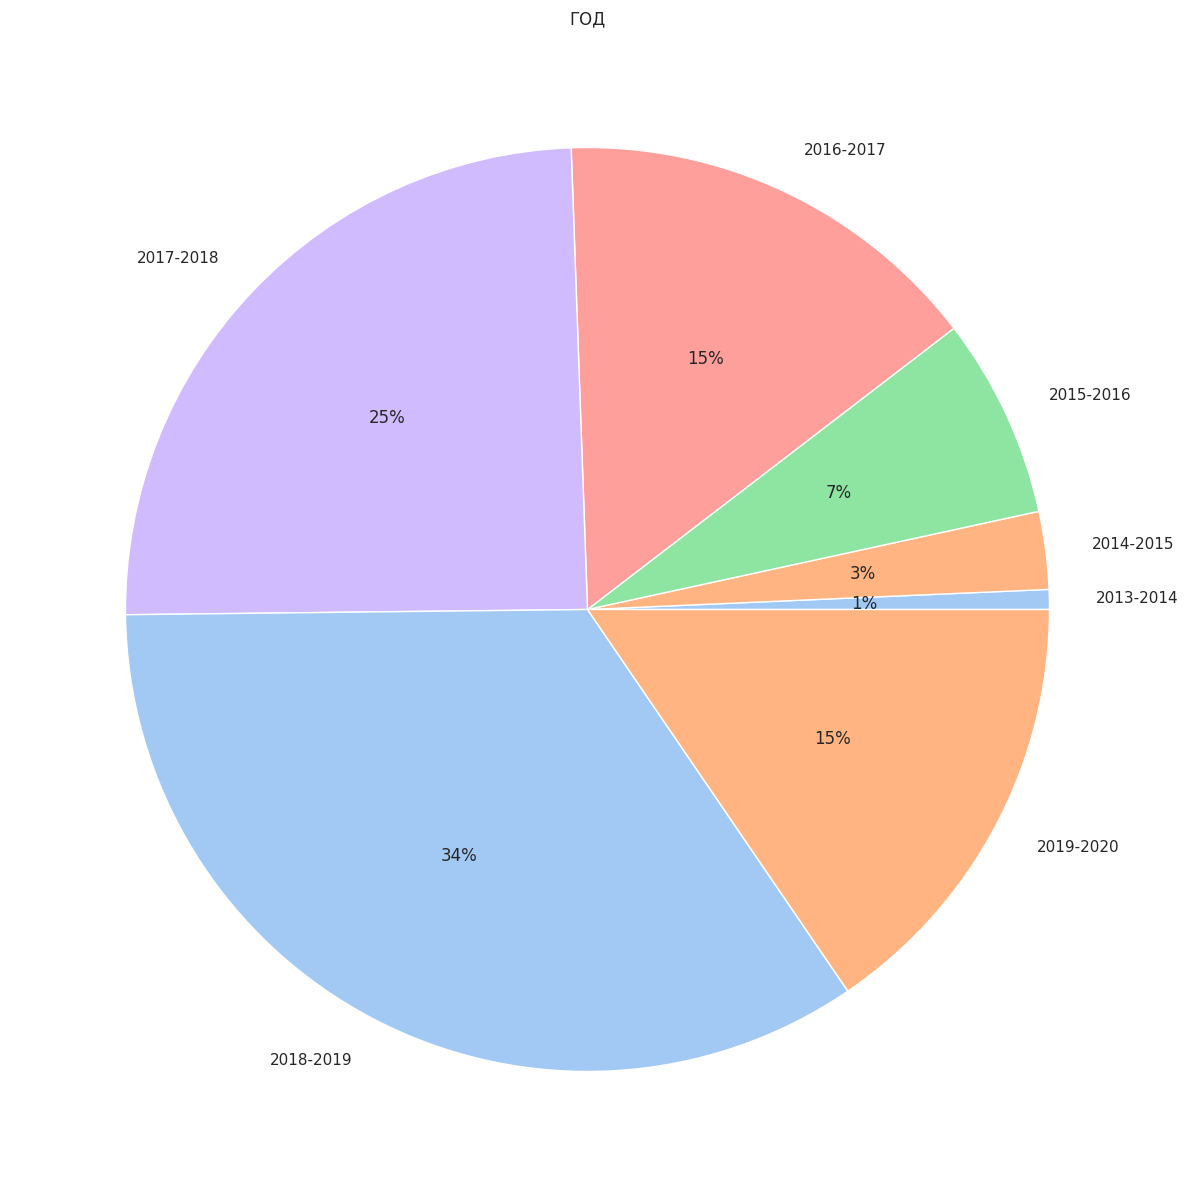

In [37]:
sns.set(rc={'figure.figsize': (15, 15)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['ГОД'].unique())
dt = np.array([len(data[data['ГОД'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('ГОД')
plt.show()

Данный признак можно попробовать разделить на числовые, как год начала и окончания курса, либо оставить как категории

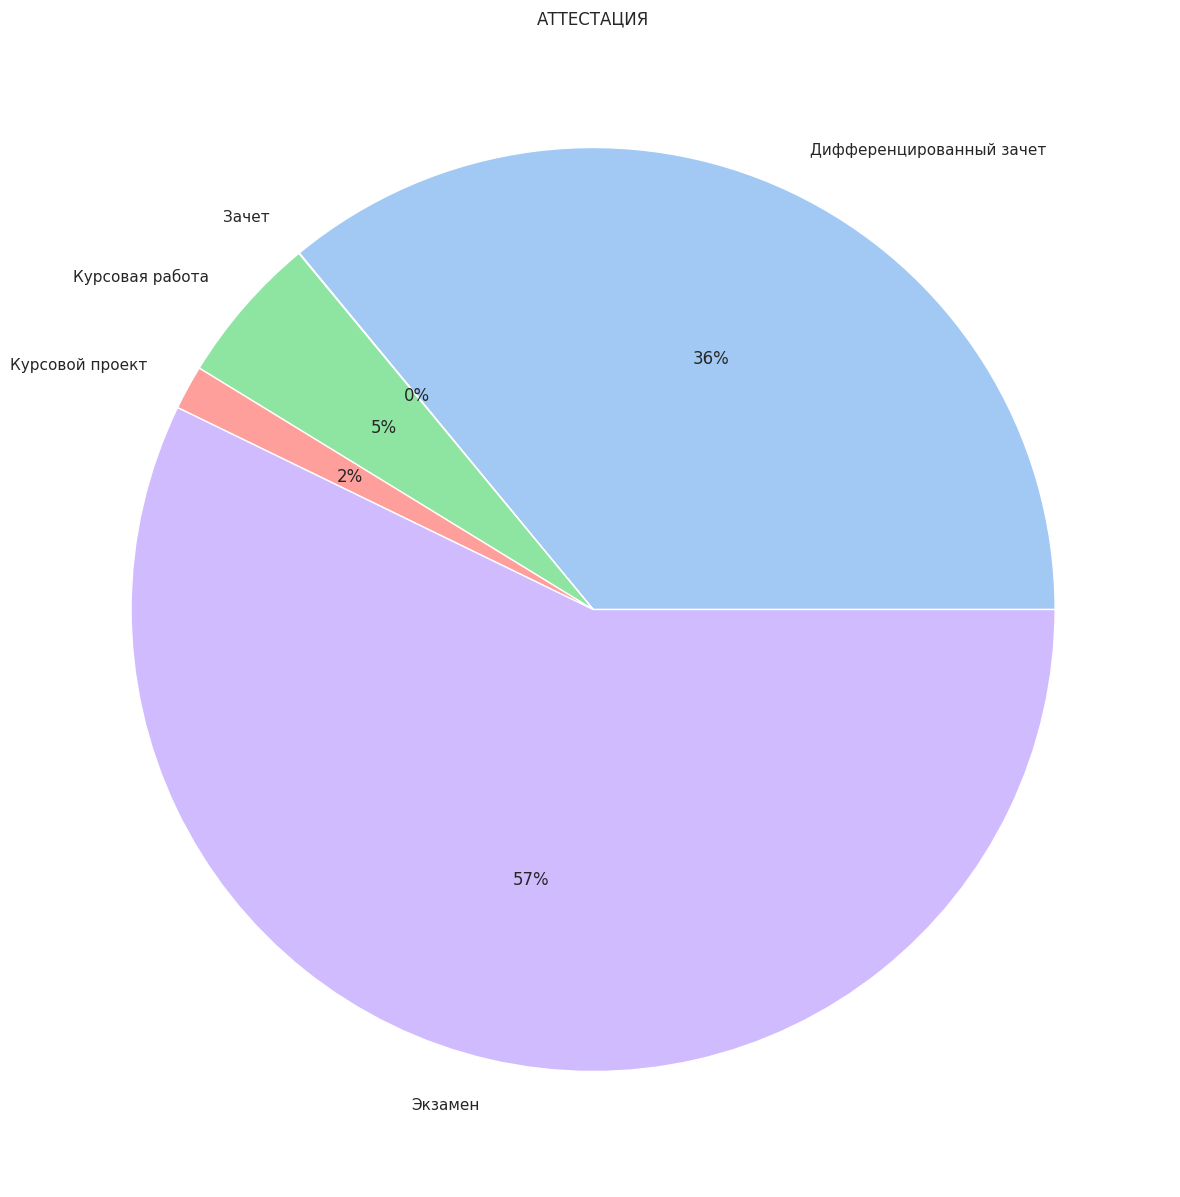

In [38]:
sns.set(rc={'figure.figsize': (15, 15)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['АТТЕСТАЦИЯ'].unique())
dt = np.array([len(data[data['АТТЕСТАЦИЯ'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('АТТЕСТАЦИЯ')
plt.show()

In [39]:
data['ДИСЦИПЛИНА'].value_counts()

ДИСЦИПЛИНА
История                                                                                    3318
Философия                                                                                  3248
Иностранный язык                                                                           3165
Математика                                                                                 2650
Физика                                                                                     2003
                                                                                           ... 
Коммуникационный менеджмент                                                                   1
Государственное регулирование в отраслях (сельское хозяйство, охота и лесное хозяйство)       1
Проектирование уникальных зданий и сооружений                                                 1
Организация предпринимательской деятельности в агропромышленном комплексе                     1
Прогнозирование и стратегичес

In [40]:
data['ДИСЦИПЛИНА'].unique(), len(data['ДИСЦИПЛИНА'].unique())

(array(['Маркетинг',
        'Пропедевтика внутренних болезней, лучевая диагностика: пропедевтика внутренних болезней',
        'Химия', ...,
        'Практикум по культуре речевого общения (первый иностранный язык)',
        'Продвижение медиапроектов в интернете',
        'Прогнозирование и стратегическое планирование в агропромышленном комплексе'],
       shape=(1400,), dtype=object),
 1400)

In [41]:
data['STD_ID'].value_counts()

STD_ID
113096    61
114302    59
114310    59
114300    59
142781    58
          ..
200986     1
199431     1
162272     1
200391     1
194047     1
Name: count, Length: 5084, dtype: int64

студенты повторяются значит их можно оставить как ещё один котегориальный признак

## Посмотрим как признаки влияют друг на друга

In [44]:
for elem in data.columns:
    if data[elem].to_numpy().dtype == object:
        print(data[elem].to_numpy().dtype)

object
object
object
object
object
object
object
object
object
object


100%|██████████| 15/15 [00:00<00:00, 193.37it/s]


<Axes: >

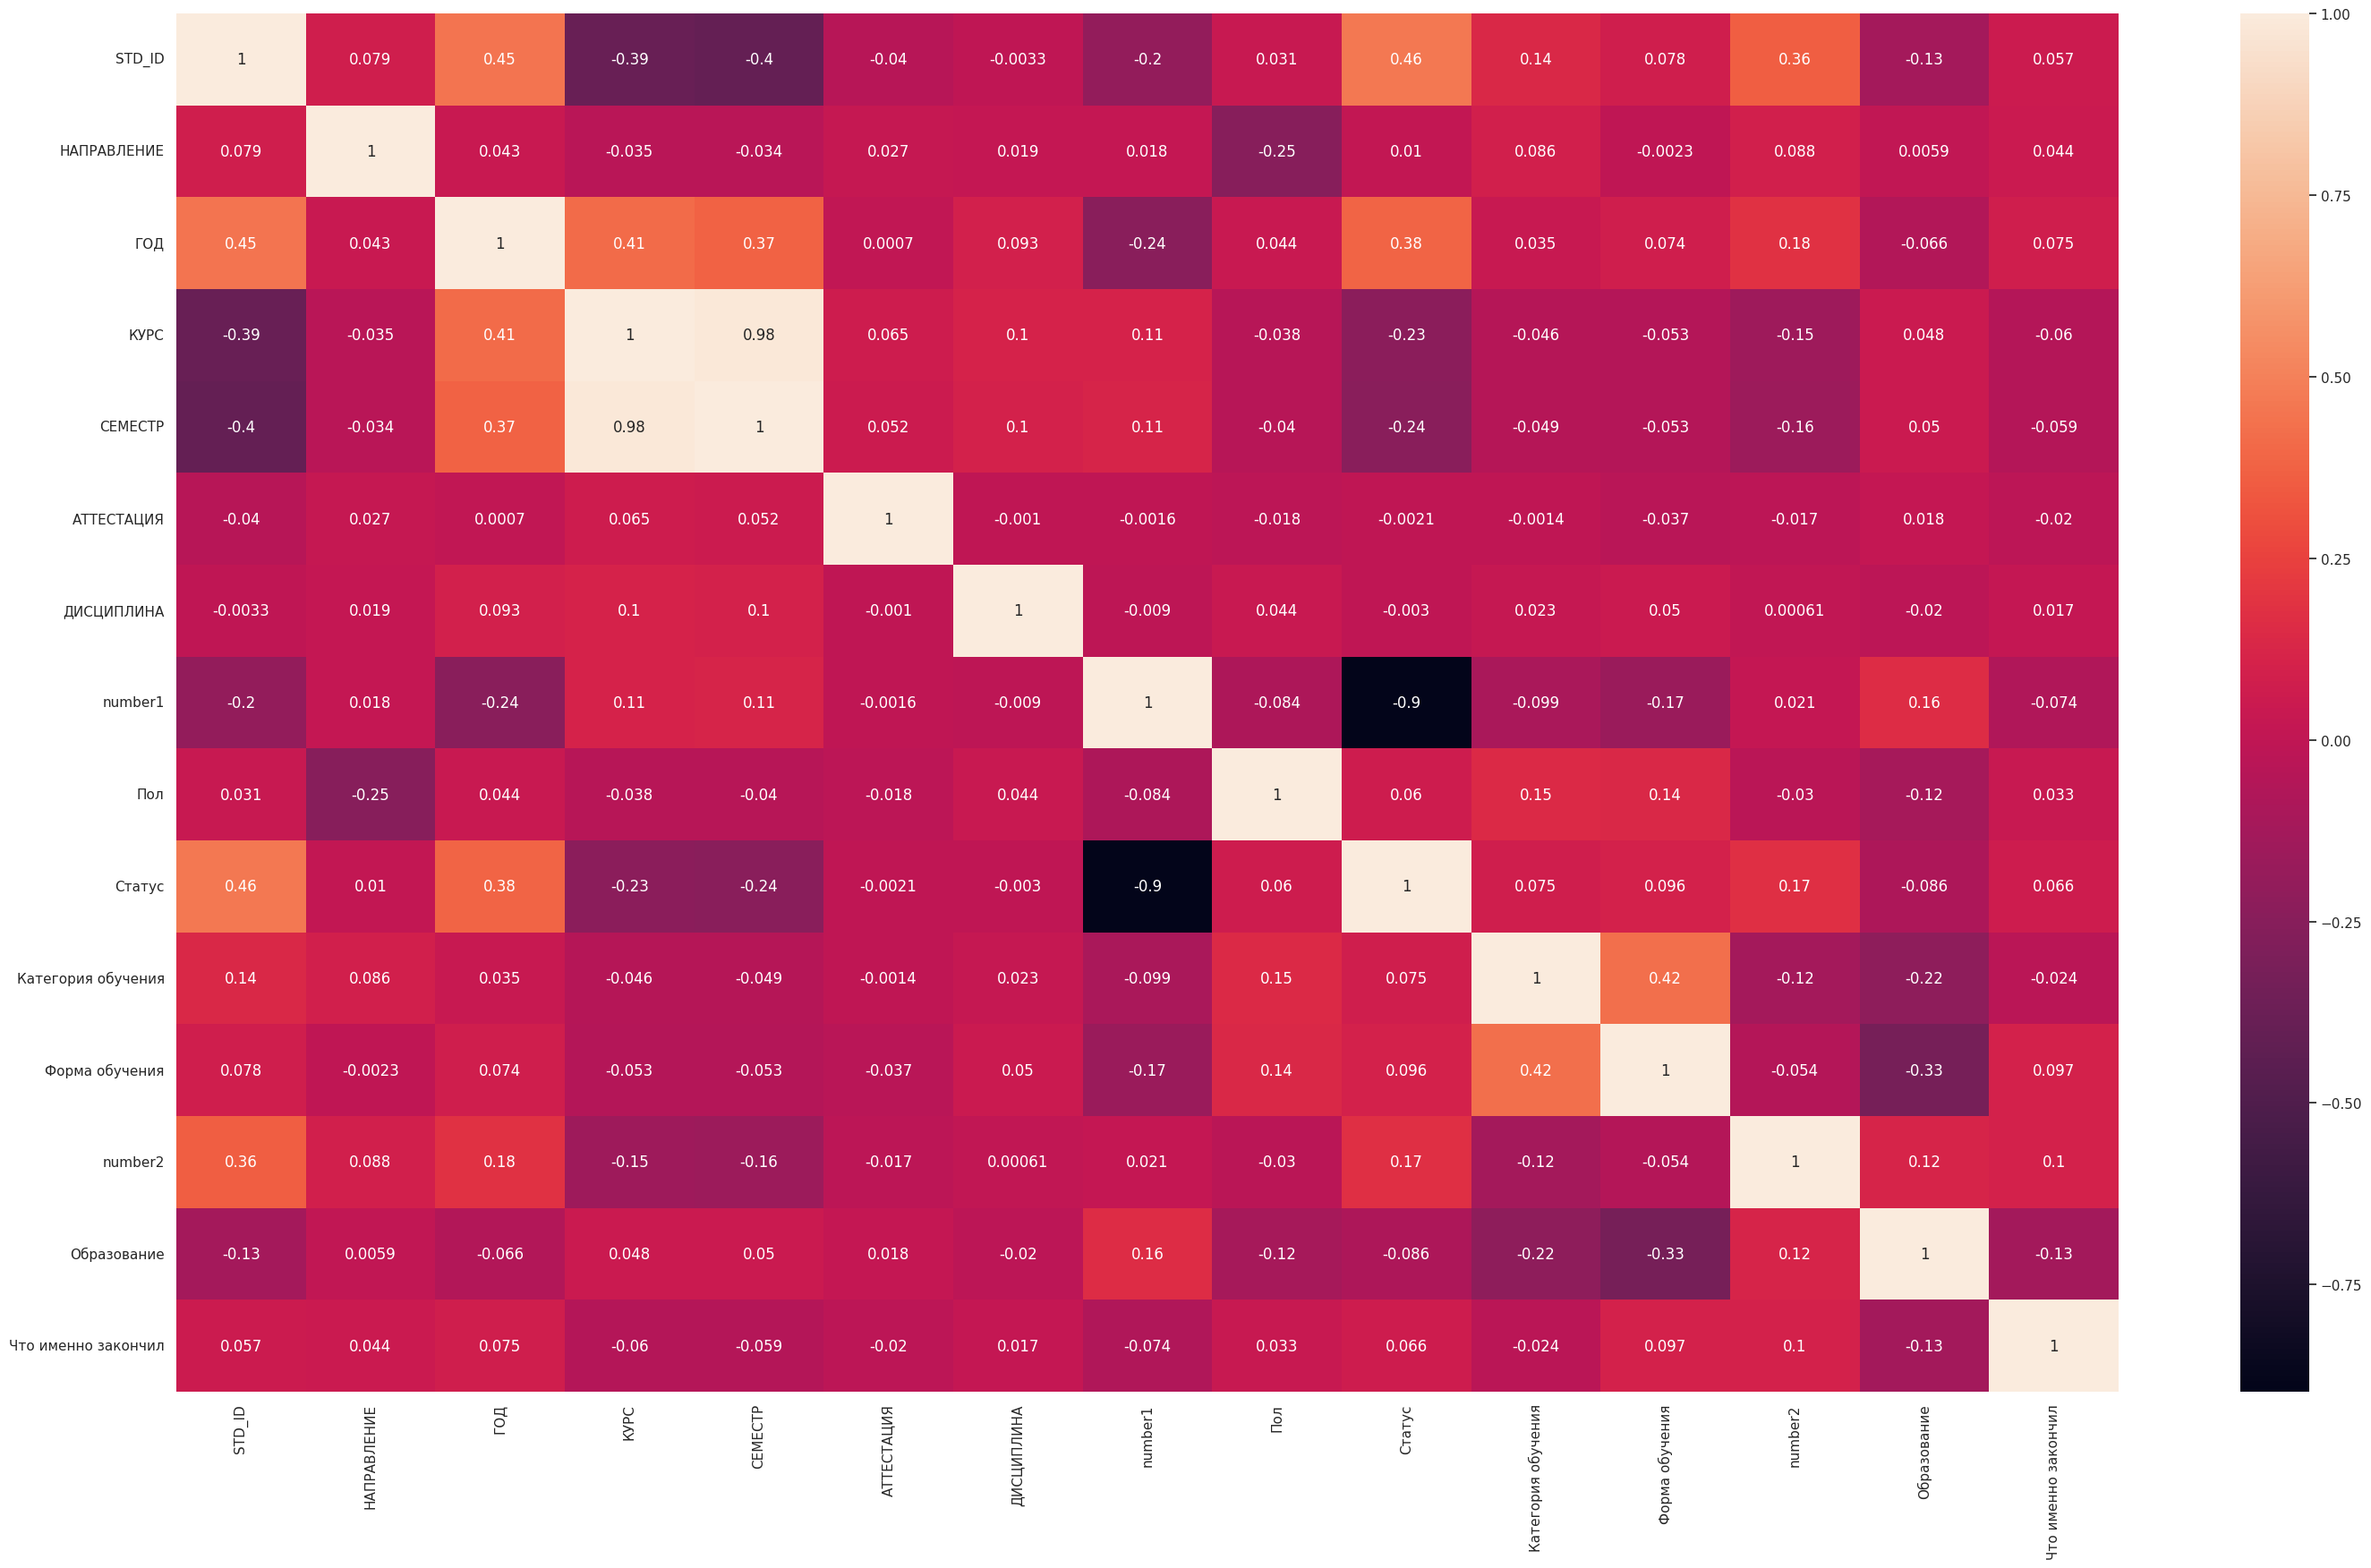

In [47]:
corr_data = data.copy()

for elem in tqdm(data.columns):
    if data[elem].to_numpy().dtype == object:
        corr_data[elem] = corr_data[elem].astype('category')
        corr_data[elem] = corr_data[elem].cat.codes

sns.set(rc={'figure.figsize': (35, 20)})

sns.heatmap(corr_data.corr(), annot=True)

In [48]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг,3989.0,М,СТ,БП,Д,5445.0,СР,"СРЕДНЯЯ ШКОЛА N 31, НОВГОРОД"
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг...",14025.0,Ж,ВЫП,ДОГ,Д,2668.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия,7212.0,Ж,СТ,БП,Д,11431.0,СР,"ГИМНАЗИЯ N 2, НОВГОРОД"
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика,3293.0,М,СТ,БП,Д,4981.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия,875.0,Ж,СТ,ДОГ,Д,2034.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право,861.0,Ж,СТ,ДОГ,В,8613.0,СР,"МОУ СОШ N 1, СОЛЬЦЫ с филиалом в Куклино"
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология,3859.0,Ж,СТ,ДОГ,Д,5505.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык,6989.0,Ж,СТ,БП,Д,4900.0,СР,"ГИМНАЗИЯ N 1, НОВГОРОД"
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика,4091.0,Ж,СТ,ДОГ,З,5466.0,СР,"Гимназия ""ГАРМОНИЯ"""


# Выбор алгоритма

In [49]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder

CAT_COLS = ['НАПРАВЛЕНИЕ', 'ГОД', 'АТТЕСТАЦИЯ', 'ДИСЦИПЛИНА',
            'Пол', 'Статус', 'Категория обучения', 'Форма обучения',
            'Образование', 'Что именно закончил']
NUM_COLS = ['КУРС', 'СЕМЕСТР']  # number1/number2 убираем — это псевдо-ID
HISTORY_COLS = ['stud_mean_grade', 'stud_count', 'discipline_mean_grade', 'direction_mean_grade']
FEATURES = CAT_COLS + NUM_COLS + HISTORY_COLS

Y = pd.read_csv('./onti-students-performance/y_train.csv')['mark'].loc[data.index].reset_index(drop=True)
data_r = data.reset_index(drop=True)

# Реалистичный (kaggle-style) split: случайно по строкам.
# Тот же студент может быть и в train, и в valid → смесь warm/cold, как в реальном тесте.
train_idx, valid_idx = train_test_split(np.arange(len(data_r)), test_size=0.1, random_state=42)


def oof_target_mean(df, key, target, n_splits=5, seed=42):
    """Out-of-fold среднее таргета по ключу — без leakage внутри train."""
    out = pd.Series(np.nan, index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, va in kf.split(df):
        means = df.iloc[tr].groupby(key)[target.name].mean()
        out.iloc[va] = df.iloc[va][key].map(means).values
    return out


train_df = data_r.iloc[train_idx].copy()
train_df['mark'] = Y.iloc[train_idx].values

global_mean = train_df['mark'].mean()

train_df['stud_mean_grade'] = oof_target_mean(train_df, 'STD_ID', train_df['mark'])
train_df['discipline_mean_grade'] = oof_target_mean(train_df, 'ДИСЦИПЛИНА', train_df['mark'])
train_df['direction_mean_grade'] = oof_target_mean(train_df, 'НАПРАВЛЕНИЕ', train_df['mark'])
train_df['stud_count'] = train_df.groupby('STD_ID')['STD_ID'].transform('count') - 1
for c in ['stud_mean_grade', 'discipline_mean_grade', 'direction_mean_grade']:
    train_df[c] = train_df[c].fillna(global_mean)

# Полные train-средние для valid/test (модель уже обучена → не leakage).
stud_full = train_df.groupby('STD_ID')['mark'].mean()
disc_full = train_df.groupby('ДИСЦИПЛИНА')['mark'].mean()
dir_full = train_df.groupby('НАПРАВЛЕНИЕ')['mark'].mean()
stud_count_full = train_df.groupby('STD_ID').size()

valid_df = data_r.iloc[valid_idx].copy()
valid_df['stud_mean_grade'] = valid_df['STD_ID'].map(stud_full).fillna(global_mean)
valid_df['discipline_mean_grade'] = valid_df['ДИСЦИПЛИНА'].map(disc_full).fillna(global_mean)
valid_df['direction_mean_grade'] = valid_df['НАПРАВЛЕНИЕ'].map(dir_full).fillna(global_mean)
valid_df['stud_count'] = valid_df['STD_ID'].map(stud_count_full).fillna(0)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(train_df[CAT_COLS])

X_train = train_df[FEATURES].copy()
X_train[CAT_COLS] = encoder.transform(train_df[CAT_COLS])
X_valid = valid_df[FEATURES].copy()
X_valid[CAT_COLS] = encoder.transform(valid_df[CAT_COLS])

Y_train = Y.iloc[train_idx].reset_index(drop=True)
Y_valid = Y.iloc[valid_idx].reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_valid = X_valid.reset_index(drop=True)

n_warm = valid_df['STD_ID'].isin(stud_full.index).sum()
print(f'train: {len(X_train)}, valid: {len(X_valid)}')
print(f'global mean grade: {global_mean:.3f}')
print(f'warm (студент известен) в valid: {n_warm} / {len(X_valid)} ({n_warm/len(X_valid):.1%})')
X_train.head()

train: 94552, valid: 10506
global mean grade: 4.184
warm (студент известен) в valid: 10503 / 10506 (100.0%)


,НАПРАВЛЕНИЕ,ГОД,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,Пол,Статус,Категория обучения,Форма обучения,Образование,Что именно закончил,КУРС,СЕМЕСТР,stud_mean_grade,stud_count,discipline_mean_grade,direction_mean_grade
0,35.0,5.0,0.0,29.0,0.0,1.0,1.0,2.0,6.0,23.0,4.0,8.0,4.437500,20,4.121212,4.107634
1,33.0,5.0,4.0,719.0,0.0,1.0,1.0,2.0,6.0,13.0,1.0,2.0,5.000000,8,4.200000,4.736842
2,40.0,6.0,4.0,270.0,0.0,1.0,1.0,2.0,6.0,37.0,1.0,1.0,4.000000,3,3.918033,3.958343
3,44.0,5.0,4.0,1139.0,0.0,1.0,0.0,1.0,6.0,188.0,2.0,4.0,4.636364,15,4.474227,4.279893
4,24.0,4.0,4.0,945.0,0.0,1.0,0.0,1.0,6.0,162.0,3.0,6.0,4.347826,28,4.288110,4.206130


## LinearRegression

In [50]:
model_LR = LinearRegression()

model_LR.fit(X_train, Y_train)

pred_model_LR = [5 if i > 5 else abs(i) for i in model_LR.predict(X_valid)]

## SGDRegressor

In [51]:
model_SGDR = SGDRegressor()

model_SGDR.fit(X_train, Y_train)

pred_model_SGDR = [5 if i > 5 else abs(i) for i in model_SGDR.predict(X_valid)]

## GradientBoostingRegressor

In [52]:
model_GBR = GradientBoostingRegressor()

model_GBR.fit(X_train, Y_train)

pred_model_GBR = [5 if i > 5 else abs(i) for i in model_GBR.predict(X_valid)]

## RandomForestRegressor

In [54]:
model_RFR = RandomForestRegressor(random_state=42)

model_RFR.fit(X_train, Y_train)

pred_model_RFR = [5 if i > 5 else abs(i) for i in model_RFR.predict(X_valid)]

## MLPRegressor

In [55]:
model_MLPR = MLPRegressor()

model_MLPR.fit(X_train, Y_train)

pred_model_MLPR = [5 if i > 5 else abs(i) for i in model_MLPR.predict(X_valid)]

## Посмотрим на результаты

In [56]:
comparison_table = pd.DataFrame(result_table([pred_model_LR,
                                              pred_model_SGDR,
                                              pred_model_GBR,
                                              pred_model_RFR,
                                              pred_model_MLPR
                                             ],
                                              Y_valid,
                                              subcol='models',
                                              valueSubCol=['LR', 'SGDR', 'GBR', 'RFR', 'MLPR']))
comparison_table

,models,mean_squared_error,mean_absolute_error,median_absolute_error,mean_absolute_percentage_error,r2_score
0,LR,5.565227e-01,4.490496e-01,0.398094,1.141003e-01,4.570486e-01
1,SGDR,6.443147e+10,8.355037e+09,1.000000,2.004819e+09,-7.277651e+21
2,GBR,5.468555e-01,4.445271e-01,0.390839,1.128287e-01,4.757478e-01
3,RFR,5.348424e-01,4.213161e-01,0.350000,1.066792e-01,4.985279e-01
4,MLPR,5.974631e-01,4.899511e-01,0.435210,1.184252e-01,3.742263e-01


In [57]:
comparison_table[comparison_table['r2_score'] == comparison_table['r2_score'].max()]

,models,mean_squared_error,mean_absolute_error,median_absolute_error,mean_absolute_percentage_error,r2_score
3,RFR,0.534842,0.421316,0.35,0.106679,0.498528


In [58]:
sorted(comparison_table['r2_score'])

[-7.277650538315891e+21,
 0.37422629780739536,
 0.457048644481409,
 0.4757477840905562,
 0.49852785136717326]

# Подберем параметры для лучшей модели

In [59]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 15, 20, 30],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.5, 0.7],
}

rf = RandomForestRegressor(n_jobs=-1, random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search.fit(X_train, Y_train)

print('Лучшие параметры:', search.best_params_)
print(f'Лучший CV R²:    {search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7fed64227a60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/home/aliaksandr/BSUIR/students_performance/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x7f90dbb47a60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr

Лучшие параметры: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Лучший CV R²:    0.5106


Exception ignored in: <function ResourceTracker.__del__ at 0x7f08c9b47a60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f889713fa60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f0fe073fa60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

In [60]:
model_RFR = search.best_estimator_

pred_model_RFR_tuned = [5 if i > 5 else abs(i) for i in model_RFR.predict(X_valid)]

In [61]:
import numpy as np

valid_stud_ids = data_r['STD_ID'].iloc[valid_idx].reset_index(drop=True)
warm_mask = valid_stud_ids.isin(stud_full.index).values
cold_mask = ~warm_mask

pred_arr = np.array(pred_model_RFR_tuned)
y_arr = np.array(Y_valid)

print('=== Общая метрика на holdout ===')
result_pred(pred_arr, y_arr)

print(f'\n=== Warm-start (студент известен модели): {warm_mask.sum()} записей ===')
if warm_mask.sum() > 0:
    result_pred(pred_arr[warm_mask], y_arr[warm_mask])

print(f'\n=== Cold-start (новый студент): {cold_mask.sum()} записей ===')
if cold_mask.sum() > 0:
    result_pred(pred_arr[cold_mask], y_arr[cold_mask])
else:
    print('Нет cold-записей (все студенты в valid встречались в train).')

print(f'\nДоля warm в holdout: {warm_mask.mean():.1%}')

=== Общая метрика на holdout ===
mean_squared_error: 0.5206080312790492
mean_absolute_error: 0.4137556254550823
median_absolute_error: 0.34503025147006916
mean_absolute_percentage_error: 0.1048335267309678
r2_score: 0.5248651407265938

=== Warm-start (студент известен модели): 10503 записей ===
mean_squared_error: 0.5206635893801436
mean_absolute_error: 0.41380135242652943
median_absolute_error: 0.3451208381030626
mean_absolute_percentage_error: 0.10484535682297762
r2_score: 0.5248910046272033

=== Cold-start (новый студент): 3 записей ===
mean_squared_error: 0.26171761933911153
mean_absolute_error: 0.25366549841877156
median_absolute_error: 0.2522837571962535
mean_absolute_percentage_error: 0.06341637460469289
r2_score: 0.0

Доля warm в holdout: 100.0%


# Предскажем тест

In [63]:
testData = pd.read_csv('./onti-students-performance/X_test.csv').drop(columns=['Unnamed: 0'])

In [65]:
testData

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА
0,163261,35.03.04 Агрономия,2018-2019,3.0,5.0,Дифференцированный зачет,История
1,162990,23.03.03 Эксплуатация транспортно-технологичес...,2019-2020,4.0,7.0,Экзамен,Сертификация и лицензирование в сфере производ...
2,192595,40.03.01 Юриспруденция,2018-2019,1.0,2.0,Экзамен,История государства и права России
3,198675,38.03.01 Экономика,2018-2019,2.0,3.0,Дифференцированный зачет,Иностранный язык в сфере профессиональной комм...
4,162111,44.03.05 Педагогическое образование (с двумя п...,2018-2019,3.0,6.0,Экзамен,Физическая химия
...,...,...,...,...,...,...,...
26260,164804,31.05.01 Лечебное дело,2019-2020,4.0,7.0,Экзамен,"Факультетская хирургия, урология"
26261,170508,40.03.01 Юриспруденция,2019-2020,4.0,7.0,Дифференцированный зачет,Арбитражный процесс
26262,178316,31.05.03 Стоматология,2017-2018,1.0,2.0,Экзамен,"Гистология, эмбриология, цитология - гистологи..."
26263,186542,46.03.01 История,2019-2020,2.0,3.0,Дифференцированный зачет,Иностранный язык


In [66]:
testData = testData.merge(studs_info, how='left', on='STD_ID')

# Заполняем пропуски той же стратегией, что и в train.
for col in NUM_COLS:
    testData[col] = testData[col].fillna(train_df[col].mean())
for col in CAT_COLS:
    testData[col] = testData[col].fillna(train_df[col].mode()[0])

# History-фичи: для известных студентов — их train-средние; для новых — глобальное среднее.
testData['stud_mean_grade'] = testData['STD_ID'].map(stud_full).fillna(global_mean)
testData['discipline_mean_grade'] = testData['ДИСЦИПЛИНА'].map(disc_full).fillna(global_mean)
testData['direction_mean_grade'] = testData['НАПРАВЛЕНИЕ'].map(dir_full).fillna(global_mean)
testData['stud_count'] = testData['STD_ID'].map(stud_count_full).fillna(0)

# Применяем тот же encoder.
testData_X = testData[FEATURES].copy()
testData_X[CAT_COLS] = encoder.transform(testData_X[CAT_COLS])
print(f'test: {len(testData_X)}, известных студентов: {testData["STD_ID"].isin(stud_full.index).sum()}')

test: 26265, известных студентов: 26253


In [67]:
testData.isnull().sum()

STD_ID                   0
НАПРАВЛЕНИЕ              0
ГОД                      0
КУРС                     0
СЕМЕСТР                  0
АТТЕСТАЦИЯ               0
ДИСЦИПЛИНА               0
number1                  0
Пол                      0
Статус                   0
Категория обучения       0
Форма обучения           0
number2                  0
Образование              0
Что именно закончил      0
stud_mean_grade          0
discipline_mean_grade    0
direction_mean_grade     0
stud_count               0
dtype: int64

In [68]:
import joblib
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error

Y_predTest = [5 if i > 5 else abs(i) for i in model_RFR.predict(testData_X)]

ART_DIR = Path('./artifacts')
ART_DIR.mkdir(exist_ok=True)

categories = {col: list(map(str, c)) for col, c in zip(CAT_COLS, encoder.categories_)}
studs_for_meta = data.drop_duplicates(['STD_ID'])[
    ['STD_ID', 'Пол', 'Статус', 'Категория обучения', 'Форма обучения',
     'Образование', 'Что именно закончил']
]

joblib.dump(model_RFR, ART_DIR / 'model.pkl')
joblib.dump(encoder, ART_DIR / 'encoder.pkl')
joblib.dump({
    'model_type': 'sklearn',
    'best_name': 'RandomForest (tuned, with history features)',
    'cat_cols': CAT_COLS,
    'num_cols': NUM_COLS,
    'history_cols': HISTORY_COLS,
    'features': FEATURES,
    'categories': categories,
    'studs_info': studs_for_meta.to_dict(orient='records'),
    'global_mean': float(global_mean),
    'stud_full': stud_full.to_dict(),       # warm-start: средняя оценка студента
    'stud_count': stud_count_full.to_dict(),
    'disc_full': disc_full.to_dict(),       # средняя по дисциплине
    'dir_full': dir_full.to_dict(),         # средняя по направлению
    'metrics': {
        'r2_score': float(r2_score(Y_valid, pred_model_RFR_tuned)),
        'mean_absolute_error': float(mean_absolute_error(Y_valid, pred_model_RFR_tuned)),
    },
}, ART_DIR / 'meta.pkl')
print(f'Saved. R²={r2_score(Y_valid, pred_model_RFR_tuned):.4f}, MAE={mean_absolute_error(Y_valid, pred_model_RFR_tuned):.4f}')

Saved. R²=0.5249, MAE=0.4138


In [69]:
submission = pd.read_csv('./onti-students-performance/sample_submission.csv')

In [70]:
submission['mark'] = Y_predTest

In [71]:
submission.to_csv('sub.csv', index=False)

In [72]:
pd.read_csv('sub.csv')

,index,mark
0,56065,4.061822
1,304637,4.174500
2,177437,3.856867
3,222396,4.184371
4,271996,3.935712
...,...,...
26260,49838,4.403980
26261,273753,3.603899
26262,35426,3.415235
26263,160476,4.127636


Exception ignored in: <function ResourceTracker.__del__ at 0x7f716f93fa60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
